# Ćwiczenia z sieci neuronowych z PyTorch - sieci grafowe

## 1. Reprezentacja grafu

Graf definiujemy przez wierzchołki (atomy) oraz krawędzie (wiązania). Użyjemy formatu zdefiniowanego przez [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/), ale bez użycia tej biblioteki.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem

### Tworzenie grafu z zapisu SMILES (Simplified Molecular-Input Line-Entry System)

In [2]:
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    # Typy węzłów (np. liczby atomowe: 6 dla węgla, 8 dla tlenu)
    node_types = np.array([atom.GetAtomicNum() for atom in mol.GetAtoms()])
    
    sources = []
    destinations = []
    edge_attrs = []
    
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        # Typ wiązania (1.0, 1.5, 2.0, 3.0)
        bt = int(bond.GetBondTypeAsDouble())
        
        # Grafy molekularne są nieskierowane, dodajemy krawędzie w obu kierunkach
        sources.extend([start, end])
        destinations.extend([end, start])
        edge_attrs.extend([bt, bt])
        
    edge_index = np.array([sources, destinations])
    edge_attrs = np.array(edge_attrs)
    
    # Konwersja do tensorów PyTorch
    return {
        'x': torch.tensor(node_types, dtype=torch.long),
        'edge_index': torch.tensor(edge_index, dtype=torch.long),
        'edge_attr': torch.tensor(edge_attrs, dtype=torch.long)
    }

# Przykład: Etanol (C2H5OH)
graph_data = smiles_to_graph("CCO")
print("Węzły (liczby atomowe):", graph_data['x'])
print("Krawędzie (src, dst):\n", graph_data['edge_index'])
print("Cechy krawędzi (typ wiązania):", graph_data['edge_attr'])

Węzły (liczby atomowe): tensor([6, 6, 8])
Krawędzie (src, dst):
 tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])
Cechy krawędzi (typ wiązania): tensor([1, 1, 1, 1])


## 2. Message passing - przepływ wiadomości

Podstawową operacją w Graph Neural Networks jest tzw. message passing. Składa się on z 3 kroków (dla każdego węzła docelowego i połączonych krawędzi):
1. **Message**: Stworzenie wiadomości ze źródłowego węzła, krawędzi i węzła docelowego.
2. **Aggregation**: Zebranie wiadomości od wszystkich sąsiadów w jeden wektor.
3. **Update**: Aktualizacja stanu węzła na podstawie jego poprzedniego stanu i zebranych wiadomości.

Najpierw zbudujmy to ręcznie.

In [10]:
embedding_dim = 4
hidden_dim = 8

# Embeddings zamieniają identyfikatory (liczby atomowe, typy wiązań) na gęste wektory
node_embedder = nn.Embedding(num_embeddings=100, embedding_dim=embedding_dim)
edge_embedder = nn.Embedding(num_embeddings=10, embedding_dim=embedding_dim)

# Sieć do generowania wiadomości
# wejście: (node_src, node_dst, edge_attr) -> rozmiar: embedding_dim * 3
msg_net = nn.Linear(embedding_dim * 3, hidden_dim)

# Sieć do aktualizacji węzła
# wejście: (stary_stan_węzła, zagregowana_wiadomość) -> rozmiar: embedding_dim + hidden_dim
update_net = nn.Linear(hidden_dim + embedding_dim, embedding_dim)

### Implementacja 1 kroku Message Passing na zmiennych

In [12]:
x_embedded = node_embedder(graph_data['x'])
edge_attrs_embedded = edge_embedder(graph_data['edge_attr'])
src, dst = graph_data['edge_index']

print("Stan początkowy (x):\n", x_embedded)

# 1. Message
# Tworzymy wejście konkatenując wektory: źródła, celu i krawędzi
msg_inputs = torch.cat([x_embedded[src], x_embedded[dst], edge_attrs_embedded], dim=-1)
messages = torch.relu(msg_net(msg_inputs))

# 2. Aggregation
# Sumujemy wiadomości trafiające do tego samego węzła docelowego (dst)
aggr_msg = torch.zeros(x_embedded.size(0), messages.size(-1))
# index_add_ dodaje wiersze z `messages` do wierszy w `aggr_msg` bazując na indeksach `dst`
aggr_msg.index_add_(dim=0, index=dst, source=messages)

# 3. Update
out = torch.relu(update_net(torch.cat([x_embedded, aggr_msg], dim=-1)))

print("\nStan węzłów po 1 kroku MPNN (out):\n", out)

Stan początkowy (x):
 tensor([[-0.2665,  0.8765,  1.2648, -0.8123],
        [-0.2665,  0.8765,  1.2648, -0.8123],
        [ 0.6225,  1.5552, -0.2006, -0.2660]], grad_fn=<EmbeddingBackward0>)

Stan węzłów po 1 kroku MPNN (out):
 tensor([[0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000],
        [0.1205, 0.0000, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)


## 3. Agregacja (Readout) grafu

Po kilku warstwach MPNN (Message Passing Neural Network) chcemy na podstawie cech *pojedynczych węzłów* przewidzieć właściwość *całej cząsteczki*. Należy dokonać agregacji cech węzłów (tzw. global pooling).

In [15]:
# Sum pooling - dodajemy wektory wszystkich węzłów cząsteczki
global_graph_vector = out.sum(dim=0)

# Dodajemy małą "głowę" klasyfikacyjną/regresyjną (MLP)
head_mlp = nn.Sequential(
    nn.Linear(embedding_dim, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

predykcja = head_mlp(global_graph_vector)
print("Predykcja dla grafu:", predykcja.item())

Predykcja dla grafu: -0.03849102556705475


## 4. Message Passing jako moduł (nn.Module)

Złóżmy powyższą ręczną implementację w klasy ułatwiające budowanie głębszych sieci.

In [16]:
class MPNNLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()
        self.msg_net = nn.Sequential(
            nn.Linear(node_dim * 2 + edge_dim, hidden_dim),
            nn.ReLU()
        )
        self.update_net = nn.Sequential(
            nn.Linear(hidden_dim + node_dim, node_dim),
            nn.ReLU()
        )
        
    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        
        # 1. Message
        msg_inputs = torch.cat([x[src], x[dst], edge_attr], dim=-1)
        messages = self.msg_net(msg_inputs)
        
        # 2. Aggregation
        aggr_msg = torch.zeros(x.size(0), messages.size(-1), device=x.device)
        aggr_msg.index_add_(0, dst, messages)
        
        # 3. Update
        out = self.update_net(torch.cat([x, aggr_msg], dim=-1))
        
        # Połączenie rezydualne ułatwia trening głębokich sieci grafowych
        return out + x

class SimpleGNN(nn.Module):
    def __init__(self, node_emb_dim=8, edge_emb_dim=4, hidden_dim=16):
        super().__init__()
        self.node_embedder = nn.Embedding(100, node_emb_dim)
        self.edge_embedder = nn.Embedding(10, edge_emb_dim)
        
        self.layer1 = MPNNLayer(node_emb_dim, edge_emb_dim, hidden_dim)
        self.layer2 = MPNNLayer(node_emb_dim, edge_emb_dim, hidden_dim)
        
        self.head = nn.Sequential(
            nn.Linear(node_emb_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        
    def forward(self, graph):
        x = self.node_embedder(graph['x'])
        e = self.edge_embedder(graph['edge_attr'])
        idx = graph['edge_index']
        
        # Propagacja
        x = self.layer1(x, idx, e)
        x = self.layer2(x, idx, e)
        
        # Global Pooling (suma)
        graph_repr = x.sum(dim=0)
        
        return self.head(graph_repr)

## 5. Trening GNN

Zbudujmy fikcyjny zestaw danych i wytrenujmy model. Przewidujemy ilość atomów (jako zadanie regresji testowe).

Epoch   0 | Train Loss: 7.2814 | Val Loss: 0.0492
Epoch  10 | Train Loss: 0.0188 | Val Loss: 0.0437
Epoch  20 | Train Loss: 0.0082 | Val Loss: 0.0188
Epoch  30 | Train Loss: 0.0443 | Val Loss: 0.0520
Epoch  40 | Train Loss: 0.0001 | Val Loss: 0.0034
Epoch  50 | Train Loss: 0.0001 | Val Loss: 0.0035
Epoch  60 | Train Loss: 0.0029 | Val Loss: 0.0011
Epoch  70 | Train Loss: 0.0801 | Val Loss: 0.0068
Epoch  80 | Train Loss: 0.0001 | Val Loss: 0.0084
Epoch  90 | Train Loss: 0.0000 | Val Loss: 0.0080
Koniec! Najlepszy val loss: 0.0008845282233475397


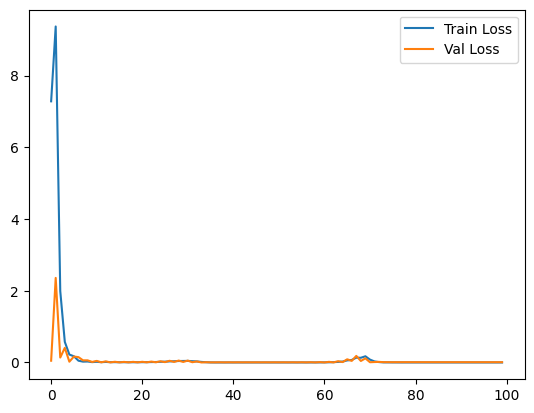

In [17]:
import random
import copy

smiles_list = ["C", "CC", "CCC", "CCO", "CO", "CCN", "CC(=O)O", "c1ccccc1", "O=C=O", "N"]
# Targets: liczba atomów ciężkich (nie-wodoru)
dataset = []
for s in smiles_list:
    g = smiles_to_graph(s)
    if g is not None:
        target = torch.tensor([float(len(g['x']))])
        dataset.append((g, target))

# Podział train/val
random.shuffle(dataset)
train_data = dataset[:7]
val_data = dataset[7:]

model = SimpleGNN(node_emb_dim=16, edge_emb_dim=8, hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_wts = None
epochs = 100

for epoch in range(epochs):
    # TRAIN
    model.train()
    train_losses = []
    # Dla uproszczenia batch_size=1
    for graph, target in train_data:
        optimizer.zero_grad()
        pred = model(graph)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
    avg_tr_loss = np.mean(train_losses)
    history['train_loss'].append(avg_tr_loss)
    
    # EVAL
    model.eval()
    val_losses = []
    with torch.no_grad():
        for graph, target in val_data:
            pred = model(graph)
            loss = criterion(pred, target)
            val_losses.append(loss.item())
            
    avg_val_loss = np.mean(val_losses)
    history['val_loss'].append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_wts = copy.deepcopy(model.state_dict())
        
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train Loss: {avg_tr_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

model.load_state_dict(best_wts)
print("Koniec! Najlepszy val loss:", best_val_loss)

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

## 6. Zadanie końcowe (Quest): Przewidywanie rozpuszczalności (ESOL)

Wykorzystaj wiedzę z dzisiejszych zajęć, aby wytrenować model GNN na prawdziwym zbiorze danych ESOL (rozpuszczalność cząsteczek). Wczytamy dane z pliku `dane/esol.csv`, a Twoim zadaniem będzie zdefiniowanie hiperparametrów i uruchomienie pętli uczącej, aby uzyskać jak najmniejszy błąd (MSE) na zbiorze walidacyjnym.

In [18]:
import pandas as pd
import os

# Ścieżka do pliku
csv_path = 'dane/esol.csv'
df = pd.read_csv(csv_path)
print(f'Wczytano {len(df)} cząsteczek.')
df.head()

Wczytano 1128 cząsteczek.


,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [19]:
# Przygotowanie danych do PyTorcha
esol_dataset = []
for idx, row in df.iterrows():
    smiles = row['SMILES']
    label = row['label']
    
    g = smiles_to_graph(smiles)
    if g is not None:
        # Etykieta jako tensor [1]
        target = torch.tensor([float(label)], dtype=torch.float32)
        esol_dataset.append((g, target))
        
print(f'Poprawnie przetworzono {len(esol_dataset)} grafów.')

# Mieszamy i dzielimy na zbiór treningowy i walidacyjny (np. 80% / 20%)
random.seed(42)
random.shuffle(esol_dataset)
split_idx = int(0.8 * len(esol_dataset))

train_esol = esol_dataset[:split_idx]
val_esol = esol_dataset[split_idx:]
print(f'Train: {len(train_esol)}, Val: {len(val_esol)}')

Poprawnie przetworzono 1128 grafów.
Train: 902, Val: 226


Poniżej zainicjuj model `SimpleGNN`, optymalizator (np. Adam) oraz funkcję straty (MSELoss). Następnie napisz pętlę uczącą na kilkadziesiąt epok. Powodzenia!

Epoch   0 | Train MSE: 1.6430 | Val MSE: 1.2470
Epoch   5 | Train MSE: 0.7991 | Val MSE: 0.7417
Epoch  10 | Train MSE: 0.7200 | Val MSE: 0.7066
Epoch  15 | Train MSE: 0.6755 | Val MSE: 0.6791
Epoch  20 | Train MSE: 0.6141 | Val MSE: 0.6446
Epoch  25 | Train MSE: 0.5678 | Val MSE: 0.5973
Epoch  30 | Train MSE: 0.5301 | Val MSE: 0.5915
Epoch  35 | Train MSE: 0.5267 | Val MSE: 0.5794
Epoch  40 | Train MSE: 0.4924 | Val MSE: 0.5506
Epoch  45 | Train MSE: 0.4694 | Val MSE: 0.5524
Epoch  50 | Train MSE: 0.4645 | Val MSE: 0.5457
Epoch  55 | Train MSE: 0.4590 | Val MSE: 0.5779
Epoch  60 | Train MSE: 0.4306 | Val MSE: 0.5613
Epoch  65 | Train MSE: 0.4170 | Val MSE: 0.5465
Epoch  70 | Train MSE: 0.4030 | Val MSE: 0.5011
Epoch  75 | Train MSE: 0.3779 | Val MSE: 0.4995
Epoch  80 | Train MSE: 0.3744 | Val MSE: 0.4857
Epoch  85 | Train MSE: 0.3649 | Val MSE: 0.5035
Epoch  90 | Train MSE: 0.3475 | Val MSE: 0.5393
Epoch  95 | Train MSE: 0.3538 | Val MSE: 0.4517
Trening zakończony! Najlepszy Val MSE: 0

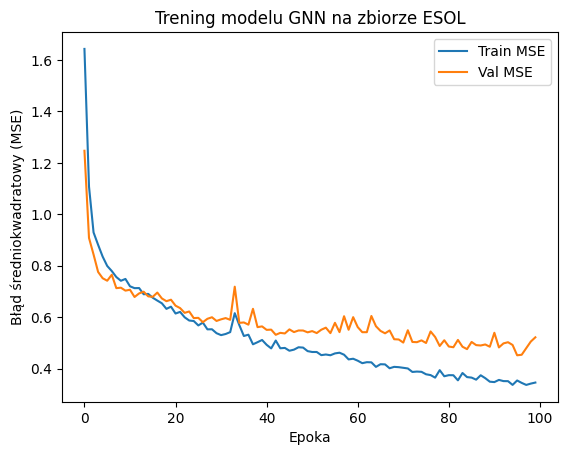

In [20]:
# model_esol = SimpleGNN(node_emb_dim=16, edge_emb_dim=8, hidden_dim=32)
model_esol = SimpleGNN(node_emb_dim=16, edge_emb_dim=16, hidden_dim=64)

# optimizer_esol = torch.optim.Adam(model_esol.parameters(), lr=0.005)
optimizer_esol = torch.optim.Adam(model_esol.parameters(), lr=0.001)
criterion_esol = nn.MSELoss()

esol_history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_wts_esol = None
epochs_esol = 100

for epoch in range(epochs_esol):
    # TRAIN
    model_esol.train()
    train_losses = []
    for graph, target in train_esol:
        optimizer_esol.zero_grad()
        pred = model_esol(graph)
        loss = criterion_esol(pred, target)
        loss.backward()
        optimizer_esol.step()
        train_losses.append(loss.item())
        
    avg_tr_loss = np.mean(train_losses)
    esol_history['train_loss'].append(avg_tr_loss)
    
    # EVAL
    model_esol.eval()
    val_losses = []
    with torch.no_grad():
        for graph, target in val_esol:
            pred = model_esol(graph)
            loss = criterion_esol(pred, target)
            val_losses.append(loss.item())
            
    avg_val_loss = np.mean(val_losses)
    esol_history['val_loss'].append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_wts_esol = copy.deepcopy(model_esol.state_dict())
        
    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | Train MSE: {avg_tr_loss:.4f} | Val MSE: {avg_val_loss:.4f}')

model_esol.load_state_dict(best_wts_esol)
print("Trening zakończony! Najlepszy Val MSE:", best_val_loss)

plt.figure()
plt.plot(esol_history['train_loss'], label='Train MSE')
plt.plot(esol_history['val_loss'], label='Val MSE')
plt.title("Trening modelu GNN na zbiorze ESOL")
plt.xlabel("Epoka")
plt.ylabel("Błąd średniokwadratowy (MSE)")
plt.legend()
plt.show()